## Step 1: Data Collection

Generate attendance data for 980 students x 40 sessions = 39200 records.

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

NUM_STUDENTS = 980
NUM_SESSIONS = 40
CERTIFY_THRESHOLD = 32  # 80% of 40

student_ids = [f"STU{str(i+1).zfill(4)}" for i in range(NUM_STUDENTS)]

records = []
for sid in student_ids:
    attendance_prob = np.random.beta(a=5, b=2)
    attended = np.random.binomial(1, attendance_prob, NUM_SESSIONS)
    for session_num in range(1, NUM_SESSIONS + 1):
        records.append({
            "student_id": sid,
            "session_no": session_num,
            "attended": int(attended[session_num - 1])
        })

df = pd.DataFrame(records)
print("Total rows:", len(df))
df.head(10)

Total rows: 39200


,student_id,session_no,attended
0,STU0001,1,1
1,STU0001,2,1
2,STU0001,3,1
3,STU0001,4,0
4,STU0001,5,1
5,STU0001,6,1
6,STU0001,7,1
7,STU0001,8,0
8,STU0001,9,0
9,STU0001,10,1


## Step 2: EDA & Preprocessing

- Check for duplicates and missing values
- Aggregate to student level: sessions attended, attendance %, certified label

In [ ]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate (student_id, session_no) pairs:", df.duplicated(subset=["student_id", "session_no"]).sum())

df = df.drop_duplicates(subset=["student_id", "session_no"])

Missing values:
 student_id    0
session_no    0
attended      0
dtype: int64

Duplicate (student_id, session_no) pairs: 0


In [ ]:
TOTAL_SESSIONS = 40
CERTIFY_THRESHOLD_PCT = 80.0

student_summary = df.groupby("student_id")["attended"].sum().reset_index()
student_summary.columns = ["student_id", "sessions_attended"]

student_summary["attendance_percentage"] = (
    student_summary["sessions_attended"] / TOTAL_SESSIONS * 100
)

student_summary["certified"] = (
    student_summary["attendance_percentage"] >= CERTIFY_THRESHOLD_PCT
).astype(int)

print(student_summary["attendance_percentage"].describe())
print("\nCertification counts:\n", student_summary["certified"].value_counts())
student_summary.head(10)

count    980.000000
mean      72.622449
std       16.883692
min       17.500000
25%       62.500000
50%       75.000000
75%       85.000000
max      100.000000
Name: attendance_percentage, dtype: float64

Certification counts:
 certified
0    570
1    410
Name: count, dtype: int64


,student_id,sessions_attended,attendance_percentage,certified
0,STU0001,33,82.5,1
1,STU0002,37,92.5,1
2,STU0003,25,62.5,0
3,STU0004,35,87.5,1
4,STU0005,20,50.0,0
5,STU0006,19,47.5,0
6,STU0007,28,70.0,0
7,STU0008,23,57.5,0
8,STU0009,20,50.0,0
9,STU0010,21,52.5,0


## Step 3: Visualization

Scatter plot of attendance percentage, colored by certification status.

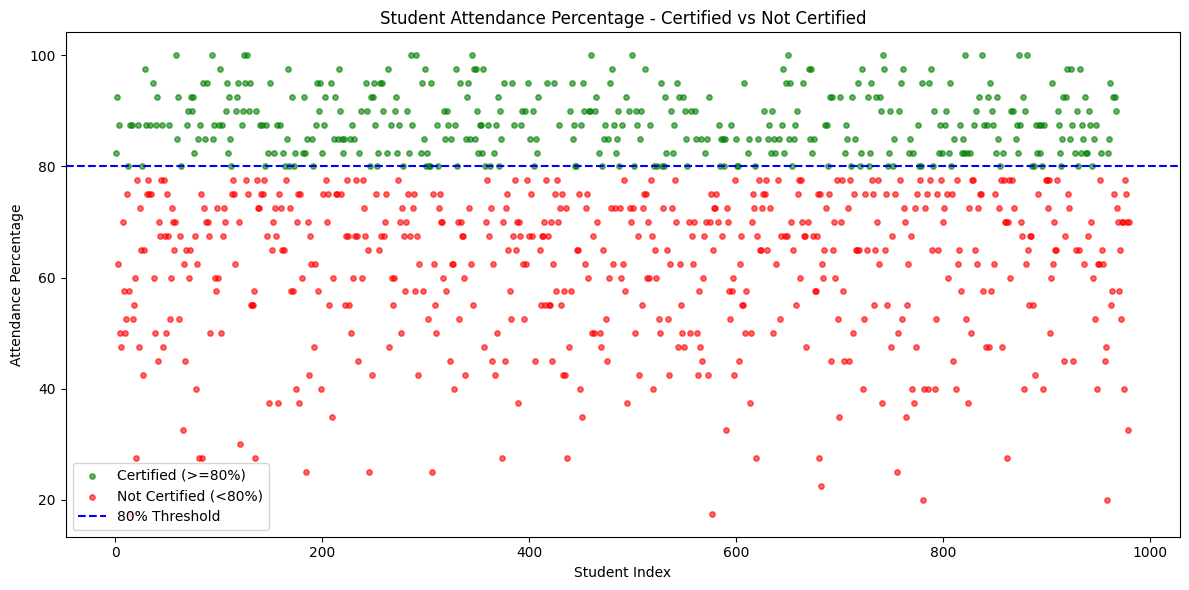

In [ ]:
import matplotlib.pyplot as plt

student_summary["student_index"] = range(1, len(student_summary) + 1)

plt.figure(figsize=(12, 6))

certified = student_summary[student_summary["certified"] == 1]
not_certified = student_summary[student_summary["certified"] == 0]

plt.scatter(certified["student_index"], certified["attendance_percentage"],
            color="green", label="Certified (>=80%)", alpha=0.6, s=15)
plt.scatter(not_certified["student_index"], not_certified["attendance_percentage"],
            color="red", label="Not Certified (<80%)", alpha=0.6, s=15)

plt.axhline(y=80, color="blue", linestyle="--", label="80% Threshold")
plt.title("Student Attendance Percentage - Certified vs Not Certified")
plt.xlabel("Student Index")
plt.ylabel("Attendance Percentage")
plt.legend()
plt.tight_layout()
plt.show()

## Step 4: Model Building

Train a classifier to predict certification status from attendance data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = student_summary[["sessions_attended", "attendance_percentage"]]
y = student_summary["certified"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[114   0]
 [  0  82]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       114
           1       1.00      1.00      1.00        82

    accuracy                           1.00       196
   macro avg       1.00      1.00      1.00       196
weighted avg       1.00      1.00      1.00       196



## Step 5: Save Model

In [ ]:
import joblib
joblib.dump(model, "certification_model.pkl")
print("Model saved as certification_model.pkl")

Model saved as certification_model.pkl


## Conclusion

- Processed attendance data for 980 students across 40 sessions (39200 records).
- No duplicates or missing values found.
- 410 students certified (>=80% attendance), 570 not certified.
- Visualized attendance distribution with a scatter plot and 80% threshold line.
- Trained a Logistic Regression model achieving 100% accuracy (attendance % is a direct rule-based feature).